In [2]:
import numpy as np  # Аналитическое решение. (№8)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# Сетка с границами
x = np.linspace(0, 2, 100)
y = np.linspace(0, 2, 100)
X, Y = np.meshgrid(x, y)

In [4]:
def analytical_solution(x, y):
    term1 = -2 * np.cosh(np.pi * y) * np.sin(np.pi * x) / np.cosh(np.pi)
    term2 = -(np.sinh(np.pi * x / 2) * np.cos(np.pi * y)) / np.sinh(np.pi)
    return term1 + term2


Z_analytical = analytical_solution(X, Y)

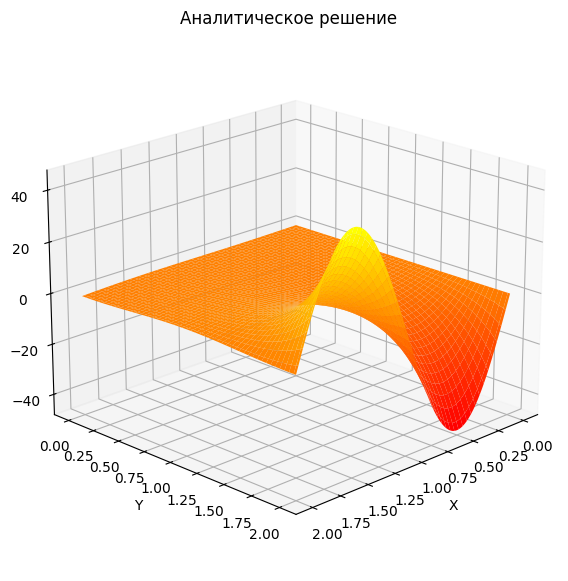

In [7]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z_analytical, cmap='autumn')
ax.view_init(elev=20, azim=45)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U(x, y)')
ax.set_title('Аналитическое решение')
plt.show()

In [18]:
nx, ny = 100, 100
x = np.linspace(0, 2, nx)  # x ∈ [0, 2]
y = np.linspace(0, 1, ny)  # y ∈ [0, 1]
X, Y = np.meshgrid(x, y)

In [19]:
dx = x[1] - x[0]
dy = y[1] - y[0]
U = np.zeros((ny, nx))

In [20]:
# Граничные условия
U[:, 0] = 0                        # U(0, y) = 0
U[:, -1] = -np.cos(np.pi * y / 2)  # U(2, y) = -cos(pi * y / 2)
U[0, :] = U[1, :]                 # ∂U/∂y(x, 0) = 0 (Неймана снизу)
U[-1, :] = -2 * np.sin(np.pi * x)  # U(x, 1) = -2 * sin(pi * x)


In [21]:
max_iter = 5000
tolerance = 1e-6

for iteration in range(max_iter):
    U_old = U.copy()
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            U[i, j] = 0.25 * (U_old[i + 1, j] + U_old[i - 1, j] +
                              U_old[i, j + 1] + U_old[i, j - 1])

    # Обновление граничных условий
    U[:, 0] = 0  # U(0, y) = 0
    U[:, -1] = -np.cos(np.pi * y / 2)  # U(2, y) = -cos(pi * y / 2)
    U[0, :] = U[1, :]  # ∂U/∂y(x, 0) = 0
    U[-1, :] = -2 * np.sin(np.pi * x)  # U(x, 1) = -2 sin(pi x)


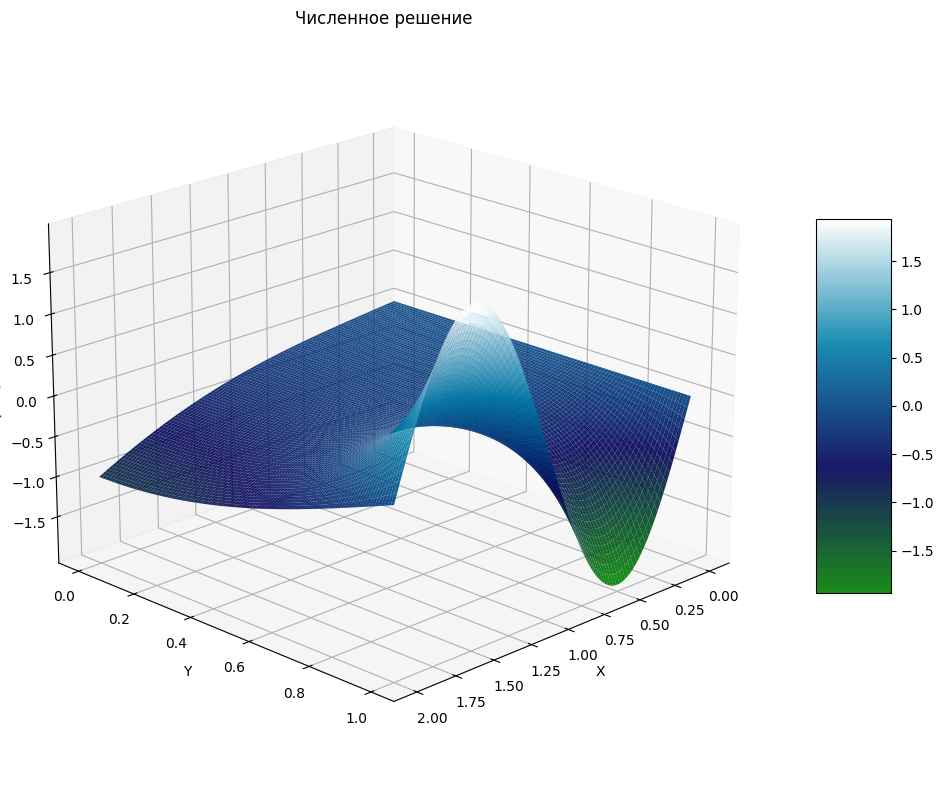

In [23]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, U, cmap='ocean', rstride=1, cstride=1, alpha=0.9)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U(x, y)')
ax.set_title('Численное решение')

ax.view_init(elev=20, azim=45)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()